## Linear Regression

Linear regression is a supervised learning algorithm used to predict continuous numerical values. It models the relationship between input features and a target variable by fitting a straight line or hyperplane that minimizes the prediction error. It is widely applied in tasks such as price prediction, demand forecasting, and trend analysis.

In [1]:
import os

# Scientific and vector computation for python
import numpy as np

# Plotting library
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # needed to plot 3-D surfaces

# tells matplotlib to embed plots within the notebook
%matplotlib inline

## Linear regression with one variable

Up next, we will implement linear regression with one variable to predict profits for a food truck. 
The file `Data/data_linear_regression1.txt` contains the dataset for our linear regression problem. The first column is the population of a city (in 10,000s) and the second column is the profit of a food truck in that city (in $10,000s). A negative value for profit indicates a loss. 

In [2]:
# Read csv file
data = np.loadtxt('Data/data_linear_regression1.csv', delimiter=',')
X, y = data[:, 0], data[:, 1]

# number of training examples
m = y.size

### Plotting the Data

In [3]:
def plot_data(x, y):
    """
    Plots the data points x and y into a new figure.
    
    Parameters
    ----------
    x : array_like
        Data point values for x-axis.

    y : array_like
        Data point values for y-axis. Note x and y should have the same size.
    """
    # open a new figure
    fig = pyplot.figure()
    
    # ms is the market size; mec is the marker edge color
    pyplot.plot(x, y, color="green", marker="o", linestyle="", ms=10, mec='k')
    pyplot.ylabel('Profit in $10,000')
    pyplot.xlabel('Population of City in 10,000s')

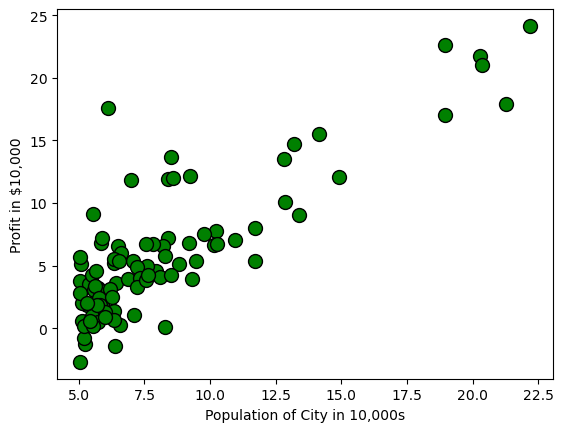

In [4]:
plot_data(X, y)

### Gradient Descent

Gradient descent is an optimization algorithm used to minimize a model’s error by iteratively adjusting its parameters. At each step, it moves in the direction of the negative gradient (the steepest decrease) of the cost function, gradually finding the parameter values that produce the lowest prediction error.

The objective of linear regression is to minimize the cost function

$$ J(\theta) = \frac{1}{2m} \sum_{i=1}^m \left( h_{\theta}(x^{(i)}) - y^{(i)}\right)^2$$

where the hypothesis $h_\theta(x)$ is given by the linear model
$$ h_\theta(x) = \theta^Tx = \theta_0 + \theta_1 x_1$$

Recall that the parameters of your model are the $\theta_j$ values. These are
the values you will adjust to minimize cost $J(\theta)$. One way to do this is to
use the batch gradient descent algorithm. In batch gradient descent, each
iteration performs the update

$$ \theta_j = \theta_j - \alpha \frac{1}{m} \sum_{i=1}^m \left( h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)} \qquad \text{simultaneously update } \theta_j \text{ for all } j$$

With each step of gradient descent, parameters $\theta_j$ come closer to the optimal values that will achieve the lowest cost J($\theta$).

In [5]:
# Add a column of ones to X. The numpy function stack joins arrays along a given axis. 
# Don't execute this cell more than once.
# The first axis (axis=0) refers to rows (training examples) 
# and second axis (axis=1) refers to columns (features).
X = np.stack([np.ones(m), X], axis=1)

#### Computing the cost $J(\theta)$

In [6]:
def compute_cost(X, y, theta):
    """
    Compute cost for linear regression.
    
    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n+1), where m is the number of examples,
        and n is the number of features. We assume a vector of one's already 
        appended to the features so we have n+1 columns.
    
    y : array_like
        The values of the function at each data point. This is a vector of
        shape (m, ).
    
    theta : array_like
        The parameters for the regression function. This is a vector of 
        shape (n+1, ).
    
    Returns
    -------
    J : float
        The value of the regression cost function.
    """
    # number of training examples
    m = y.size

    hypothesis = X.dot(theta)  # m X 1
    J =  (1/(2*m)) * np.sum(np.power((hypothesis - y), 2)) 
    
    return J

Let's run `compute_cost` twice, using two different initializations of $\theta$. The cost will be printed to the screen.

In [7]:
J = compute_cost(X, y, theta=np.array([0.0, 0.0]))
print('With theta = [0, 0] \nCost computed = %.2f' % J)

# further testing of the cost function
J = compute_cost(X, y, theta=np.array([-1, 2]))
print('With theta = [-1, 2]\nCost computed = %.2f' % J)

With theta = [0, 0] 
Cost computed = 32.07
With theta = [-1, 2]
Cost computed = 54.24


#### Gradient descent

In [8]:
def gradient_descent(X, y, theta, alpha, num_iters):
    """
    Performs gradient descent to learn `theta`. Updates theta by taking `num_iters`
    gradient steps with learning rate `alpha`.
    
    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n+1).
    
    y : array_like
        Value at given features. A vector of shape (m, ).
    
    theta : array_like
        Initial values for the linear regression parameters. 
        A vector of shape (n+1, ).
    
    alpha : float
        The learning rate.
    
    num_iters : int
        The number of iterations for gradient descent. 
    
    Returns
    -------
    theta : array_like
        The learned linear regression parameters. A vector of shape (n+1, ).
    
    J_history : list
        A python list for the values of the cost function after each iteration.

    """

    # number of training examples
    m = y.shape[0]
    
    # make a copy of theta, to avoid changing the original array, since numpy arrays
    # are passed by reference to functions
    theta_modified = np.copy(theta)
    
    J_history = []
    
    for i in range(num_iters):
        for j in range(0,len(theta)):
            hypothesis = X.dot(theta)  # m X 1
            theta_modified[j] = theta[j] - alpha/m * np.sum((hypothesis - y) * X[:,j])
        
        theta = np.copy(theta_modified)    
        
        # save the cost J in every iteration
        J_history.append(compute_cost(X, y, theta))
    
    return theta, J_history

Let's call the implemented `gradient_descent` function and print the computed $\theta$. We initialize the $\theta$ parameters to 0 and the learning rate $\alpha$ to 0.01.

In [9]:
# initialize fitting parameters
theta = np.zeros(2)

# some gradient descent settings
iterations = 1500
alpha = 0.01

theta, J_history = gradient_descent(X ,y, theta, alpha, iterations)
print('Theta found by gradient descent: {:.4f}, {:.4f}'.format(*theta))

Theta found by gradient descent: -3.6303, 1.1664


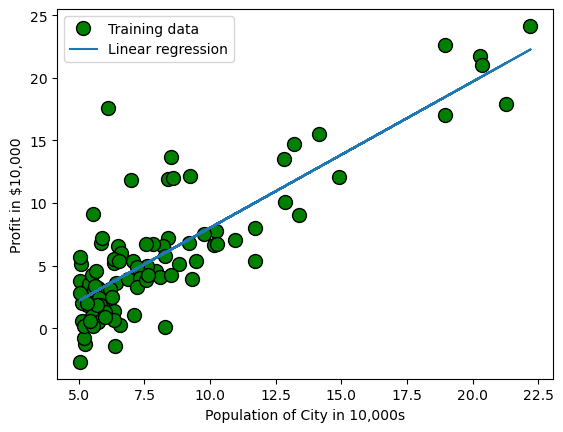

In [10]:
# plot the linear fit
plot_data(X[:, 1], y)
pyplot.plot(X[:, 1], np.dot(X, theta), '-')
pyplot.legend(['Training data', 'Linear regression']);

In [11]:
# Predict values for population sizes of 35,000 and 70,000
predict1 = np.dot([1, 3.5], theta)
print('For population = 35,000, we predict a profit of {:.2f}\n'.format(predict1*10000))

predict2 = np.dot([1, 7], theta)
print('For population = 70,000, we predict a profit of {:.2f}\n'.format(predict2*10000))

For population = 35,000, we predict a profit of 4519.77

For population = 70,000, we predict a profit of 45342.45



## Linear regression with multiple variables

We'll implement linear regression with multiple variables to predict the prices of houses. Suppose you are selling your house and you want to know what a good market price would be. One way to do this is to first collect information on recent houses sold and make a model of housing prices.

The file `Data/data_linear_regression2.csv` contains a training set of housing prices in US. The first column is the size of the house (in square feet), the second column is the number of bedrooms, and the third column is the price of the house. 

### Feature Normalization

We start by loading and displaying some values from this dataset. By looking at the values, note that house sizes are about 1000 times the number of bedrooms. When features differ by orders of magnitude, first performing feature scaling can make gradient descent converge much more quickly.

In [12]:
# Load data
data = np.loadtxt('Data/data_linear_regression2.csv', delimiter=',')
X = data[:, :2]
y = data[:, 2]
m = y.size

# print out some data points
# The > character specifies that the text should be right-aligned within the designated space (in this case 8 or 10, the the field width)
# The s character specifies that the value should be treated as a string
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    # 8: This specifies a field width of 8 characters. 
    #.0f: This specifies that the number should be formatted as a floating-point number (f) with zero decimal places (.0). 
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

  X[:,0] X[:, 1]         y
--------------------------
    2104       3    399900
    1600       3    329900
    2400       3    369000
    1416       2    232000
    3000       4    539900
    1985       4    299900
    1534       3    314900
    1427       3    198999
    1380       3    212000
    1494       3    242500


In `feature_normalize` function:
- Subtract the mean value of each feature from the dataset.
- After subtracting the mean, additionally scale (divide) the feature values by their respective “standard deviations.”

The standard deviation is a way of measuring how much variation there is in the range of values of a particular feature (most data points will lie within ±2 standard deviations of the mean); this is an alternative to taking the range of values (max-min).

Each column of the matrix $X$ corresponds to one feature.

In [13]:
def feature_normalize(X):
    """
    Normalizes the features in X. returns a normalized version of X where
    the mean value of each feature is 0 and the standard deviation
    is 1. This is often a good preprocessing step to do when working with
    learning algorithms.
    
    Parameters
    ----------
    X : array_like
        The dataset of shape (m x n).
    
    Returns
    -------
    X_norm : array_like
        The normalized dataset of shape (m x n).
    
    Note that X is a matrix where each column is a feature and each row is
    an example. We need to perform the normalization separately for each feature. 
    
    """
    
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    for i in range(0, len(mu)): 
        mu[i] = np.mean(X[:,i])   # Calculate and store the mean
        sigma[i] = np.std(X[:,i]) # Compute the standard deviation for each feature

     # Avoid division by zero by replacing zeros in sigma with 1
    sigma_no_zeros = np.where(sigma == 0, 1, sigma)

    # Numpy vectorization - it broadcasts the array values, so the vector turns a matrix and we can subtract element by element
    X_norm = (X - mu) / sigma_no_zeros
    

    return X_norm, mu, sigma

In [14]:
print(X.shape[0])
print(X.shape[1])

47
2


In [15]:
# call feature_normalize on the loaded data
X_norm, mu, sigma = feature_normalize(X)

print('Computed mean:', mu)
print('Computed standard deviation:', sigma)

Computed mean: [2000.68085106    3.17021277]
Computed standard deviation: [7.86202619e+02 7.52842809e-01]


After the `feature_normalize` function is tested, we now add the intercept term to `X_norm`:

In [16]:
# Add intercept term to X
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)